In [938]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from os import listdir
from os.path import isfile, join
import json
import seaborn as sns

# **RANDOM**

In [939]:
# Experiments Information
d = 8
D = 120
T = 10000

In [940]:
algo_list = ['RANDOM']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [941]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_return'][-1]
        

427.7 453.1 447.8 462.9
920.5 952.1 953.2 918.0
1429.3 1187.2 1543.4 1435.8
1838.6 1842.9 1738.5 1905.6
2228.1 2373.4 2156.3 2140.4


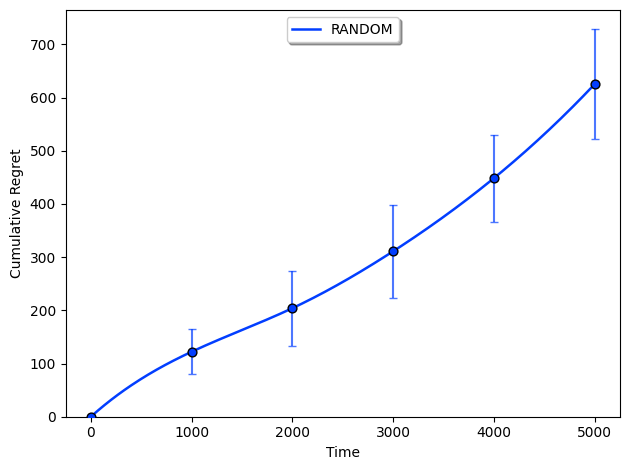

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

plt.figure()

for i in range(len(algo_list)):
    regret = [0]
    data_stds = []  # Keep track of standard deviations if needed
    timesteps = np.arange(1000, 6000, 1000)

    for t in timesteps:
        directory = f"./data/hardtolearn/{algo_list[i]}/D={D}/regret_d_{d}_D_{D}.00_T_{t}/"
        file_list = [f'results_{run}.json' for run in range(40)]

        # Parse only a subset of runs (10 in this case) for demonstration
        data = [json_parser(directory + file_list[j]) for j in range(40)] 
        print(np.mean(data[:10]), np.mean(data[10:20]), np.mean(data[20:30]), np.mean(data[30:40]))
        data_mean = np.mean(data)
        data_std = np.std(data)
        reg = 0.57 * t - data_mean
        regret.append(reg)
        data_stds.append(data_std)

    # Include initial 0-time step as the start
    all_timesteps = np.concatenate(([0], timesteps))  # prepend a 0 for the initial regret
    regret = np.array(regret)
    data_stds = np.array(data_stds)

    # Create a smooth spline fit based on the data
    # k=3 typically gives a cubic spline. If you get a RankWarning, try lowering k.
    spline = make_interp_spline(all_timesteps, regret, k=3)
    smooth_timestep = np.linspace(all_timesteps.min(), all_timesteps.max(), 300)  # 300 points for smoothness
    smooth_regret = spline(smooth_timestep)

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_list[i])

    # Optionally, show original data points
    plt.scatter(all_timesteps, regret, color=colors[i], s=40, edgecolors='k', zorder=5)

    # Optionally, show error bars at the original data points (excluding the first artificial 0)
    # Note: error bars might not make sense for the initial artificially inserted point,
    # so we handle them only for the actual data points.
    plt.errorbar(timesteps, regret[1:], yerr=0.3*data_stds, fmt='none', ecolor=colors[i], alpha=0.7, capsize=3)

plt.rc('font', size=10)
plt.rc('axes', labelsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn_RANDOM)_regret_d_{d}_D_{D}_T_{T}.pdf', dpi=300)
plt.show()


# **TSDE**

In [943]:
# Experiments Information
d = 8
D = 120
T = 10000

In [944]:
algo_list = ['TSDE']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [945]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_return'][-1]

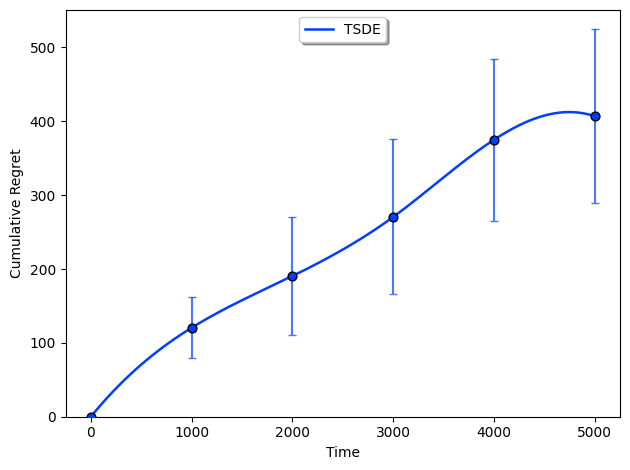

In [946]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

plt.figure()

for i in range(len(algo_list)):
    regret = [0]
    data_stds = []
    timesteps = np.arange(1000, 6000, 1000)  # Time steps from 1000 to 5000

    for t in timesteps:
        directory = f"./data/hardtolearn/{algo_list[i]}/D={D}/regret_d_{d}_D_{D}.00_T_{t}/"
        file_list = [f'results_{run}.json' for run in range(40)]

        # Parse all 40 runs
        data = [json_parser(directory + fname) for fname in file_list]

        data_mean = np.mean(data)
        data_std = np.std(data)
        reg = 0.57 * t - data_mean

        regret.append(reg)
        data_stds.append(data_std)

    # Include initial 0-time step as the start
    all_timesteps = np.concatenate(([0], timesteps))
    regret = np.array(regret)
    data_stds = np.array(data_stds)

    # Create a smooth spline fit based on the data
    # k=3 typically gives a cubic spline
    spline = make_interp_spline(all_timesteps, regret, k=3)
    smooth_timestep = np.linspace(all_timesteps.min(), all_timesteps.max(), 300)
    smooth_regret = spline(smooth_timestep)

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_list[i])

    # Plot original data points
    plt.scatter(all_timesteps, regret, color=colors[i], s=40, edgecolors='k', zorder=5)

    # Show error bars at the original data points (excluding the first artificial 0)
    plt.errorbar(timesteps, regret[1:], yerr=0.3 * data_stds, fmt='none', ecolor=colors[i], alpha=0.7, capsize=3)

# Set font sizes
plt.rc('font', size=10)
plt.rc('axes', labelsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn_TSDE)_regret_d_{d}_D_{D}_T_{T}.pdf', dpi=300)
plt.show()


# **UCRL2**

In [947]:
# Experiments Information
d = 8
D = 120
T = 10000
delta = 0.05

In [948]:
algo_list = ['UCRL2']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [950]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_return'][-1]
        

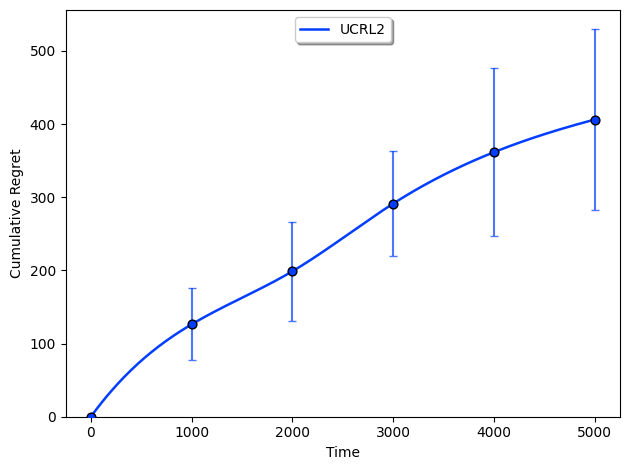

In [951]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

plt.figure()

for i in range(len(algo_list)):
    regret = [0]
    data_stds = []  # Keep track of standard deviations
    timesteps = np.arange(1000, 6000, 1000)  # 1000, 2000, 3000, 4000, 5000

    for t in timesteps:
        directory = f"./data/hardtolearn/{algo_list[i]}/D={D}/regret_d_{d}_D_{D}.00_T_{t}_delta_{delta}/"
        file_list = [f'results_{run}.json' for run in range(40)]

        data = [json_parser(directory + fname) for fname in file_list]
        data_mean = np.mean(data)
        data_std = np.std(data)
        
        reg = 0.57 * t - data_mean
        regret.append(reg)
        data_stds.append(data_std)

    # Include initial 0-time step at the start
    all_timesteps = np.concatenate(([0], timesteps))
    regret = np.array(regret)
    data_stds = np.array(data_stds)

    # Create a smooth spline fit
    spline = make_interp_spline(all_timesteps, regret, k=3)  # k=3 for cubic spline
    smooth_timestep = np.linspace(all_timesteps.min(), all_timesteps.max(), 300)  # 300 points for smoothness
    smooth_regret = spline(smooth_timestep)

    # Set font sizes
    plt.rc('font', size=10)        
    plt.rc('axes', labelsize=10)   
    plt.rc('xtick', labelsize=10)  
    plt.rc('ytick', labelsize=10)  
    plt.rc('legend', fontsize=10)

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_list[i])

    # Plot original data points
    plt.scatter(all_timesteps, regret, color=colors[i], s=40, edgecolors='k', zorder=5)

    # Add error bars at the actual data points (excluding the initial zero point)
    plt.errorbar(timesteps, regret[1:], yerr=0.3 * data_stds, fmt='none', ecolor=colors[i], alpha=0.7, capsize=3)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn_UCRL2)_regret_d_{d}_D_{D}_T_{T}.pdf', dpi=300)
plt.show()


# **UCLK-C**

In [952]:
# Experiments Information
d = 8
D = 120
T = 10000
runs = 40
delta = 0.05
epsilon = 1e-06

In [953]:
algo_list = ['UCLK_C']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [954]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_return'][-1]

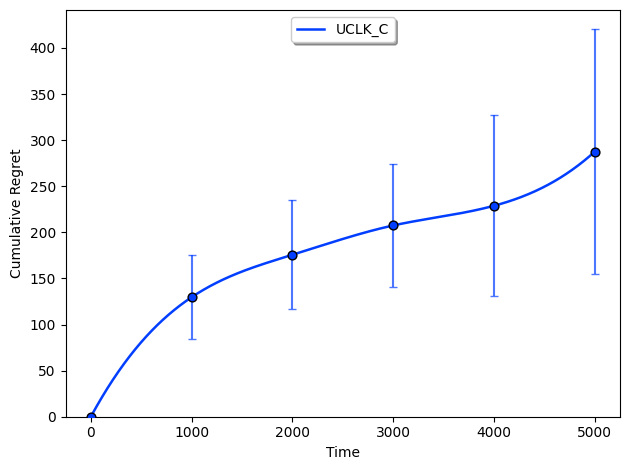

In [955]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

plt.figure()

for i in range(len(algo_list)):
    regret = [0]
    data_stds = []
    timesteps = np.arange(1000, 6000, 1000)  # 1000, 2000, ..., 10000

    for t in timesteps:
        directory = f"./data/hardtolearn/{algo_list[i]}(discrete)/D={D}/regret_d_{d}_D_{D}.00_T_{t}_delta_{delta}_epsilon_{epsilon}/"
        file_list = [f'results_{run}.json' for run in range(runs)]

        data = [json_parser(directory + fname) for fname in file_list]
        data_mean = np.mean(data)
        data_std = np.std(data)
        
        reg = 0.57 * t - data_mean
        regret.append(reg)
        data_stds.append(data_std)

    # Include initial 0-time step at the start
    all_timesteps = np.concatenate(([0], timesteps))
    regret = np.array(regret)
    data_stds = np.array(data_stds)

    # Create a smooth spline fit
    spline = make_interp_spline(all_timesteps, regret, k=3)  # cubic spline
    smooth_timestep = np.linspace(all_timesteps.min(), all_timesteps.max(), 1000)  # more points for smoothness
    smooth_regret = spline(smooth_timestep)

    # Set font sizes
    plt.rc('font', size=10)
    plt.rc('axes', labelsize=10)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=10)

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_list[i])

    # Plot original data points
    plt.scatter(all_timesteps, regret, color=colors[i], s=40, edgecolors='k', zorder=5)

    # Add error bars at the actual data points (excluding the initial zero)
    # Adjust the scaling factor of data_stds if needed (0.3 is just an example)
    plt.errorbar(timesteps, regret[1:], yerr=0.3 * data_stds, fmt='none', ecolor=colors[i], alpha=0.7, capsize=3)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn_UCLK-C)_regret_d_{d}_D_{D}_T_{T}_delta_{delta}_epsilon_{epsilon}.pdf', dpi=300)
plt.show()


# **UCRL2-VTR(Bernstein)**

In [956]:
# Experiments Information

d = 8
D = 120
T = 10000
runs = 40
delta = 0.05
epsilon = 1e-6

In [957]:
algo_list = ['UCRL2_VTR(BERNSTEIN)']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [958]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_return'][-1]        

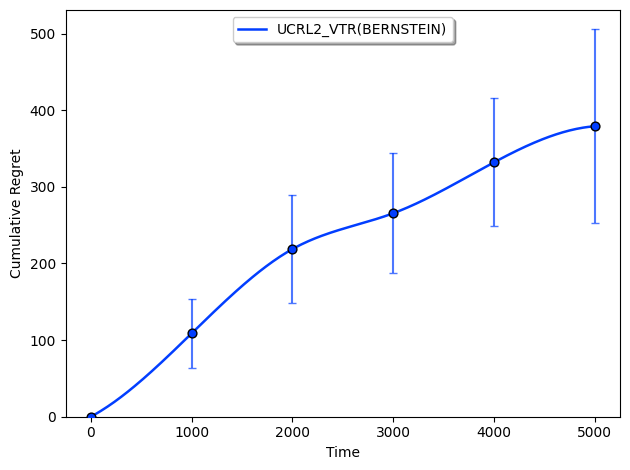

In [959]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

plt.figure()

for i in range(len(algo_list)):
    regret = [0]
    data_stds = []
    timesteps = np.arange(1000, 6000, 1000)  # 1000, 2000, 3000, 4000, 5000

    for t in timesteps:
        directory = f"./data/hardtolearn/{algo_list[i]}(discrete)/D={D}/regret_d_{d}_D_{D}.00_T_{t}_delta_{delta}_epsilon_{epsilon}/"
        # Using the provided file list pattern
        file_list = [f'results_{run}.json' for run in range(runs)]

        data = [json_parser(directory + fname) for fname in file_list]
        data_mean = np.mean(data)
        data_std = np.std(data)

        reg = 0.57 * t - data_mean
        regret.append(reg)
        data_stds.append(data_std)

    # Include initial 0-time step
    all_timesteps = np.concatenate(([0], timesteps))
    regret = np.array(regret)
    data_stds = np.array(data_stds)

    # Create a smooth spline fit
    spline = make_interp_spline(all_timesteps, regret, k=3)  # cubic spline
    smooth_timestep = np.linspace(all_timesteps.min(), all_timesteps.max(), 300)  # 300 points for smoothness
    smooth_regret = spline(smooth_timestep)

    # Set font sizes
    plt.rc('font', size=10)
    plt.rc('axes', labelsize=10)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=10)

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_list[i])

    # Plot original data points
    plt.scatter(all_timesteps, regret, color=colors[i], s=40, edgecolors='k', zorder=5)

    # Add error bars at the original data points (excluding the initial zero point)
    # Adjust the factor (0.3) for the error size if needed
    plt.errorbar(timesteps, regret[1:], yerr=0.3 * data_stds, fmt='none', ecolor=colors[i], alpha=0.7, capsize=3)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn_UCRL2-VTR(Bernstein))_regret_d_{d}_D_{D}_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}.pdf', dpi=300)
plt.show()


# **Combined Plot**

In [960]:
# Common Setting

d = 8
D = 120
T = 10000
delta = 0.05

In [961]:
algo_list_with_d = [('UCLK_C', 1e-6), ('UCRL2_VTR(BERNSTEIN)', 1e-6), ('TSDE', 0), ('UCRL2', 0), ('RANDOM', 0)]
colors = sns.color_palette('bright', n_colors=len(algo_list_with_d))

In [962]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_return'][-1]
        

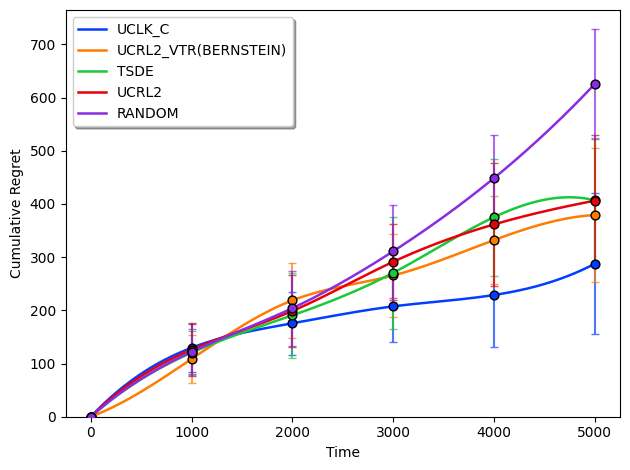

In [963]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

plt.figure()
for i in range(len(algo_list_with_d)):
    algo_name = algo_list_with_d[i][0]
    algo_eps = algo_list_with_d[i][1]

    regret = [0]
    data_stds = []
    timesteps = np.arange(1000, 6000, 1000)  # 1000, 2000, 3000, 4000, 5000

    for t in timesteps:
        if algo_name in ['TSDE', 'RANDOM']:
            directory = f"./data/hardtolearn/{algo_name}/D={D}/regret_d_{d}_D_{D}.00_T_{t}/"
        elif algo_name in ['UCRL2']:
            directory = f"./data/hardtolearn/{algo_name}/D={D}/regret_d_{d}_D_{D}.00_T_{t}_delta_{delta}/"
        else:
            directory = f"./data/hardtolearn/{algo_name}(discrete)/D={D}/regret_d_{d}_D_{D}.00_T_{t}_delta_{delta}_epsilon_{algo_eps}/"

        file_list = [f'results_{run}.json' for run in range(40)]

        data = [json_parser(directory + fname) for fname in file_list]
        data_mean = np.mean(data)
        data_std = np.std(data)

        reg = 0.57 * t - data_mean
        regret.append(reg)
        data_stds.append(data_std)

    # Include initial 0-time step
    all_timesteps = np.concatenate(([0], timesteps))
    regret = np.array(regret)
    data_stds = np.array(data_stds)

    # Create a smooth spline fit
    spline = make_interp_spline(all_timesteps, regret, k=3)  # k=3 for cubic spline
    smooth_timestep = np.linspace(all_timesteps.min(), all_timesteps.max(), 300)  # 300 points for smoothness
    smooth_regret = spline(smooth_timestep)

    # Set font sizes
    plt.rc('font', size=10)
    plt.rc('axes', labelsize=10)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=10)

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_name)

    # Plot original data points
    plt.scatter(all_timesteps, regret, color=colors[i], s=40, edgecolors='k', zorder=5)

    # Add error bars at the actual data points (excluding the initial zero point)
    # Adjust the factor (0.3) if needed for the error bar scale
    plt.errorbar(timesteps, regret[1:], yerr=0.3 * data_stds, fmt='none', ecolor=colors[i], alpha=0.7, capsize=3)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', fancybox=True, shadow=True, ncol=1)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'Total_Comparison_regret_d_{d}_D_{D}_T_{T}_delta_{delta}_epsilon_{epsilon}.pdf', dpi=300)
plt.show()
